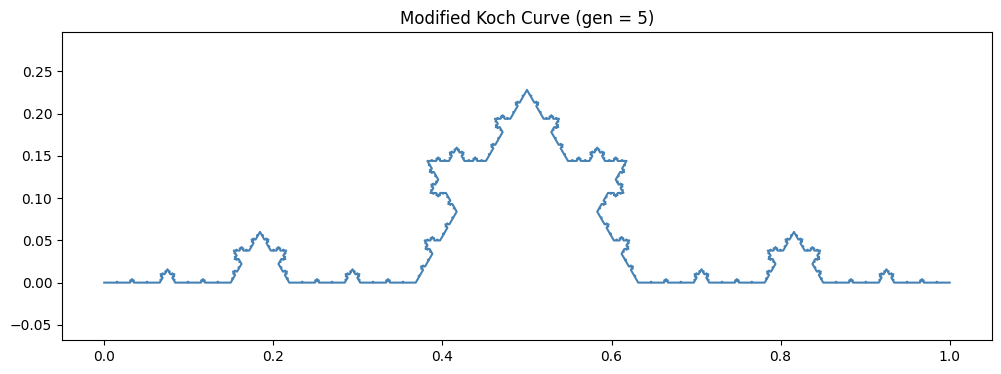

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def generate_modified_koch(points, k, max_gen,a):
    if k > max_gen:
        return points

    new_points = []
    r = (a) ** k  

    for i in range(len(points) - 1):
        A = np.array(points[i])
        B = np.array(points[i + 1])
        AB = B - A
        L = np.linalg.norm(AB)

        unit_AB = AB / L
        normal = np.array([-unit_AB[1], unit_AB[0]])  

        base_length = r 
        margin = (L - base_length) / 2

        P1 = A + unit_AB * margin          
        P2 = A + unit_AB * (margin + base_length)  
        M = (P1 + P2) / 2                   

        height = (np.sqrt(3) / 2) * base_length
        P3 = M + normal * height           
        new_points += [tuple(A), tuple(P1), tuple(P3), tuple(P2)]
    new_points.append(tuple(points[-1]))  

    return generate_modified_koch(new_points, k + 1, max_gen,a)

start = (0, 0)
end = (1, 0)
initial_points = [start, end]

gen = 5
a = (1/3.8)
curve = generate_modified_koch(initial_points, 1, gen,a)

x, y = zip(*curve)
plt.figure(figsize=(12, 4))
plt.plot(x, y, color='steelblue')
plt.axis('equal')
plt.title(f"Modified Koch Curve (gen = {gen})")
plt.show()